# Notebook 01：数据下载与股票池构建

本 Notebook 串联 `src/data/universe.py` 的原始数据下载流程与 `src/data/preprocess.py` 的预处理流程。导入、参数、函数调用和结果检查被拆成独立模块，建议按顺序逐个运行，以便在发生错误时快速定位。

默认关闭下载和预处理开关，避免执行“全部运行”时意外发起大量 Tushare 请求。确认参数后，先开启并运行下载模块，再开启并运行预处理模块。

## 模块 1：定位项目目录

In [1]:
from pathlib import Path
import sys


def find_project_root(start: Path) -> Path:
    """从当前目录向上查找包含 src/data/universe.py 的项目根目录。"""
    for candidate in (start, *start.parents):
        if (candidate / "src" / "data" / "universe.py").is_file():
            return candidate
    raise FileNotFoundError("无法定位项目根目录，请从项目目录或 notebooks 目录启动 Notebook。")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(f"项目根目录：{PROJECT_ROOT}")

项目根目录：/Users/mac/Desktop/a-share-multifactor


## 模块 2：导入函数

本模块只负责导入依赖和项目函数，不下载或处理数据。若这里报错，应先检查项目路径和依赖安装。

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.data.universe import (
    DEFAULT_RAW_DIRECTORY,
    DownloadConfig,
    run_download_pipeline,
)
from src.data.preprocess import (
    DEFAULT_PROCESSED_DIRECTORY,
    UniverseConfig,
    run_preprocess_pipeline,
)

print("项目函数导入成功。")

项目函数导入成功。


## 模块 3：配置工作流参数

下载区间比正式研究区间提前一年，为上市交易日计数、TTM 财务指标和研究初期数据匹配保留缓冲。`run_download_pipeline` 还会自动将财务报表下载起点再向前扩展一年。

In [ ]:
# 先保持为 False；确认日期、Tushare 权限和本地存储空间后再逐步开启。
RUN_DOWNLOAD = False
RUN_PREPROCESS = False

DOWNLOAD_START = "20170101"
STUDY_START = "20180101"
STUDY_END = "20251231"

RAW_DIRECTORY = DEFAULT_RAW_DIRECTORY
PROCESSED_DIRECTORY = DEFAULT_PROCESSED_DIRECTORY

download_config = DownloadConfig(
    start_date=DOWNLOAD_START,
    end_date=STUDY_END,
)
preprocess_config = UniverseConfig(
    study_start=STUDY_START,
    study_end=STUDY_END,
    min_listing_trading_days=120,
    liquidity_quantile=None,  # 如需排除成交额最低 5%，可改为 0.05。
)

In [5]:
env_path = PROJECT_ROOT / ".env"
config_summary = pd.Series(
    {
        "Tushare 配置文件存在": env_path.is_file(),
        "原始数据目录": str(RAW_DIRECTORY),
        "处理后数据目录": str(PROCESSED_DIRECTORY),
        "下载区间": f"{DOWNLOAD_START} - {STUDY_END}",
        "研究区间": f"{STUDY_START} - {STUDY_END}",
        "下载开关": RUN_DOWNLOAD,
        "预处理开关": RUN_PREPROCESS,
    },
    name="当前配置",
)
display(config_summary.to_frame())

if not env_path.is_file():
    raise FileNotFoundError(f"未找到 {env_path}，请在项目根目录创建 .env 并设置 TUSHARE_TOKEN。")

,当前配置
Tushare 配置文件存在,True
原始数据目录,/Users/mac/Desktop/a-share-multifactor/data/raw
处理后数据目录,/Users/mac/Desktop/a-share-multifactor/data/pr...
下载区间,20170101 - 20251231
研究区间,20180101 - 20251231
下载开关,True
预处理开关,False


## 模块 4：调用原始数据下载流程

将 `RUN_DOWNLOAD` 改为 `True` 后运行本单元。该函数会从项目根目录的 `.env` 读取 `TUSHARE_TOKEN`，并把 Tushare 原始数据写入 `data/raw`。日频分区已存在时会跳过，可用于断点续跑。

In [7]:
download_outputs = None

if RUN_DOWNLOAD:
    download_outputs = run_download_pipeline(
        download_config,
        raw_directory=RAW_DIRECTORY,
    )
else:
    print("未执行下载：如需下载，请将 RUN_DOWNLOAD 改为 True 后重新运行本单元。")

Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试
Tushare 请求失败，将在 4.0 秒后重试
Tushare 请求失败，将在 8.0 秒后重试
Tushare 请求失败，将在 1.0 秒后重试
Tushare 请求失败，将在 2.0 秒后重试


## 模块 5：检查原始数据下载结果

本模块不调用 Tushare，只检查下载函数返回的路径以及 `data/raw` 中各数据集的存在情况。

In [8]:
if download_outputs is None:
    print("当前会话尚未执行下载函数；下面仍会检查本地已有的原始数据。")
else:
    returned_paths = pd.DataFrame(
        [
            {"数据集": name, "路径": str(path), "存在": path.exists()}
            for name, path in download_outputs.items()
        ]
    )
    display(returned_paths)

,数据集,路径,存在
0,trade_calendar,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
1,stock_basic,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
2,daily_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
3,adj_factor_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
4,daily_basic_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
5,stk_limit_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
6,suspend_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
7,stock_st_partitions,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
8,income,/Users/mac/Desktop/a-share-multifactor/data/ra...,True
9,balancesheet,/Users/mac/Desktop/a-share-multifactor/data/ra...,True


In [9]:
raw_files = {
    "交易日历": RAW_DIRECTORY / "trade_calendar.parquet",
    "股票基础信息": RAW_DIRECTORY / "stock_basic.parquet",
    "利润表": RAW_DIRECTORY / "income.parquet",
    "资产负债表": RAW_DIRECTORY / "balancesheet.parquet",
    "申万行业历史成分": RAW_DIRECTORY / "sw_industry_membership.parquet",
}
raw_partitions = {
    "日线行情": RAW_DIRECTORY / "daily",
    "复权因子": RAW_DIRECTORY / "adj_factor",
    "每日指标": RAW_DIRECTORY / "daily_basic",
    "涨跌停价格": RAW_DIRECTORY / "stk_limit",
    "停牌记录": RAW_DIRECTORY / "suspend_d",
    "ST 记录": RAW_DIRECTORY / "stock_st",
}

raw_file_status = [
    {"数据集": name, "路径": str(path), "存在": path.is_file(), "分区数": None}
    for name, path in raw_files.items()
]
raw_partition_status = [
    {
        "数据集": name,
        "路径": str(path),
        "存在": path.is_dir(),
        "分区数": len(list(path.glob("trade_date=*.parquet"))) if path.is_dir() else 0,
    }
    for name, path in raw_partitions.items()
]
raw_status = pd.DataFrame(raw_file_status + raw_partition_status)
display(raw_status)

if not raw_status["存在"].all():
    print("警告：部分原始数据不存在。请先完成下载，再运行预处理模块。")

,数据集,路径,存在,分区数
0,交易日历,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
1,股票基础信息,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
2,利润表,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
3,资产负债表,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
4,申万行业历史成分,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,NaN
5,日线行情,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
6,复权因子,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
7,每日指标,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
8,涨跌停价格,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0
9,停牌记录,/Users/mac/Desktop/a-share-multifactor/data/ra...,True,2186.0


## 模块 6：调用预处理流程

将 `RUN_PREPROCESS` 改为 `True` 后运行本单元。`run_preprocess_pipeline` 只读取 `data/raw`，完成日频面板、point-in-time 财报、历史行业和月度股票池构建，并输出两个 Parquet 文件到 `data/processed`。

In [11]:
processed_outputs = None

if RUN_PREPROCESS:
    processed_outputs = run_preprocess_pipeline(
        preprocess_config,
        raw_directory=RAW_DIRECTORY,
        processed_directory=PROCESSED_DIRECTORY,
    )
else:
    print("未执行预处理：确认原始数据完整后，将 RUN_PREPROCESS 改为 True 并重新运行本单元。")

/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:79: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  return pd.concat((pd.read_parquet(path) for path in paths), ignore_index=True)
/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:401: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  monthly["is_st"] = monthly.pop("is_st_from_source").fillna(
/Users/mac/Desktop/a-share-multifactor/src/data/preprocess.py:419: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will ch

## 模块 7：检查预处理输出路径

本模块只检查预处理函数的输出文件，不重复执行预处理。

In [12]:
if processed_outputs is None:
    price_path = PROCESSED_DIRECTORY / "price_daily.parquet"
    universe_path = PROCESSED_DIRECTORY / "universe_monthly.parquet"
    print("当前会话尚未执行预处理函数；下面将检查本地已有的标准输出路径。")
else:
    price_path, universe_path = processed_outputs

processed_status = pd.DataFrame(
    [
        {"数据集": "日频价格面板", "路径": str(price_path), "存在": price_path.is_file()},
        {"数据集": "月度股票池", "路径": str(universe_path), "存在": universe_path.is_file()},
    ]
)
display(processed_status)

if not processed_status["存在"].all():
    print("警告：处理后文件不完整。请检查预处理模块的错误输出。")

,数据集,路径,存在
0,日频价格面板,/Users/mac/Desktop/a-share-multifactor/data/pr...,True
1,月度股票池,/Users/mac/Desktop/a-share-multifactor/data/pr...,True


## 模块 8：读取处理后数据

读取操作与预处理调用分开；因此读取失败时，可以区分是文件未生成、Parquet 引擎问题，还是后续质量检查问题。

In [13]:
price_daily = pd.read_parquet(price_path) if price_path.is_file() else None
universe_monthly = pd.read_parquet(universe_path) if universe_path.is_file() else None

if price_daily is None or universe_monthly is None:
    print("尚未加载完整的处理后数据；请先运行下载和预处理模块。")
else:
    print("两个处理后数据集均已成功读取。")

两个处理后数据集均已成功读取。


## 模块 9：字段、主键和覆盖区间检查

当前实现中，财报所属期字段保留为 `end_date`，对应 README 中的 `report_period`。若缺少最低需要字段或出现重复主键，本单元会直接报错。

In [14]:
required_price_columns = {
    "date", "stock_code", "open", "high", "low", "close",
    "prev_close", "volume", "amount", "adj_factor",
}
required_universe_columns = {
    "date", "stock_code", "list_date", "delist_date", "is_st",
    "is_suspended", "industry", "market_cap", "total_assets",
    "total_equity", "net_profit_ttm", "revenue_ttm",
    "gross_profit_ttm", "end_date", "announcement_date",
    "is_buyable", "has_core_data", "is_eligible",
}

quality_summary = None
if price_daily is not None and universe_monthly is not None:
    missing_price_columns = sorted(required_price_columns - set(price_daily.columns))
    missing_universe_columns = sorted(required_universe_columns - set(universe_monthly.columns))
    if missing_price_columns or missing_universe_columns:
        raise KeyError(
            f"price_daily 缺失字段：{missing_price_columns}；"
            f"universe_monthly 缺失字段：{missing_universe_columns}"
        )

    quality_summary = pd.DataFrame(
        [
            {
                "数据集": "price_daily",
                "行数": len(price_daily),
                "股票数": price_daily["stock_code"].nunique(),
                "起始日期": price_daily["date"].min(),
                "结束日期": price_daily["date"].max(),
                "重复主键数": price_daily.duplicated(["date", "stock_code"]).sum(),
            },
            {
                "数据集": "universe_monthly",
                "行数": len(universe_monthly),
                "股票数": universe_monthly["stock_code"].nunique(),
                "起始日期": universe_monthly["date"].min(),
                "结束日期": universe_monthly["date"].max(),
                "重复主键数": universe_monthly.duplicated(["date", "stock_code"]).sum(),
            },
        ]
    )
    display(quality_summary)

    if quality_summary["重复主键数"].ne(0).any():
        raise ValueError("发现重复的 date-stock_code 主键，请检查原始分区或合并逻辑。")

,数据集,行数,股票数,起始日期,结束日期,重复主键数
0,price_daily,9568257,5700,2017-01-03,2025-12-31,0
1,universe_monthly,436515,5696,2018-01-31,2025-12-31,0


## 模块 10：输出股票池筛选结果

`universe_monthly.parquet` 为便于审计而保留全部月末候选记录，并用 `is_eligible` 标记最终是否进入股票池。下游研究应只使用 `is_eligible == True` 的记录。

In [15]:
eligible_universe = None
monthly_summary = None

if universe_monthly is None:
    print("没有可汇总的月度股票池数据。")
else:
    eligible_universe = universe_monthly.loc[
        universe_monthly["is_eligible"].fillna(False)
    ].copy()
    monthly_summary = (
        universe_monthly.groupby("date", as_index=False)
        .agg(
            月末候选数=("stock_code", "size"),
            最终股票池数量=("is_eligible", "sum"),
            ST数量=("is_st", "sum"),
            停牌数量=("is_suspended", "sum"),
            核心数据完整数量=("has_core_data", "sum"),
        )
    )

    print(f"最终可用股票池记录数：{len(eligible_universe):,}")
    display(monthly_summary.head())
    display(eligible_universe.head())

最终可用股票池记录数：394,568


,date,月末候选数,最终股票池数量,ST数量,停牌数量,核心数据完整数量
0,2018-01-31,3291,2913,61,2,3116
1,2018-02-28,3258,2891,61,0,3081
2,2018-03-30,3278,2968,59,2,3133
3,2018-04-27,3311,3041,67,0,3168
4,2018-05-31,3326,3064,66,0,3182


,stock_code,date,open,high,low,close,prev_close,volume,amount,adj_factor,...,net_profit_ttm,gross_profit_ttm,total_assets,total_equity,industry,has_core_data,is_buyable,passes_listing_age,passes_liquidity,is_eligible
0,000001.SZ,2018-01-31,13.60,14.05,13.53,14.05,13.65,174772914.0,2.423105e+09,106.309,...,2.303300e+10,NaN,3.137481e+12,2.181110e+11,银行,True,True,True,True,True
1,000002.SZ,2018-01-31,36.61,37.76,35.62,37.56,36.36,89814786.0,3.297773e+09,137.300,...,2.385123e+10,7.684075e+10,1.018382e+12,1.163733e+11,房地产,True,True,True,True,True
2,000004.SZ,2018-01-31,21.26,21.29,20.18,20.20,21.38,834441.0,1.719262e+07,4.064,...,1.916652e+07,6.901052e+07,2.412108e+08,1.153882e+08,医药生物,True,True,True,True,True
3,000005.SZ,2018-01-31,4.11,4.13,3.98,4.03,4.14,4764194.0,1.927060e+07,9.268,...,-4.132534e+07,1.377309e+08,2.792868e+09,1.266307e+09,环保,True,True,True,True,True
4,000008.SZ,2018-01-31,8.24,8.30,8.18,8.28,8.26,5850046.0,4.823283e+07,22.052,...,4.268929e+08,9.681097e+08,9.471992e+09,6.243511e+09,机械设备,True,True,True,True,True


## 模块 11：输出每月股票池数量图

本单元对应 README 中 `figures/universe_size.png` 的输出要求。它与数据预处理分开，因此绘图失败不会掩盖前面的数据问题。

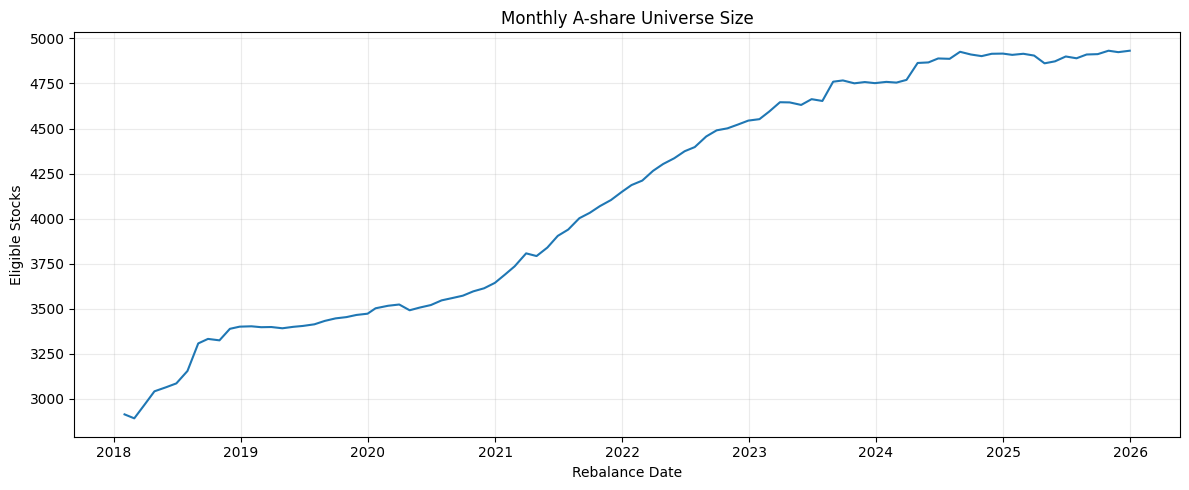

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/universe_size.png


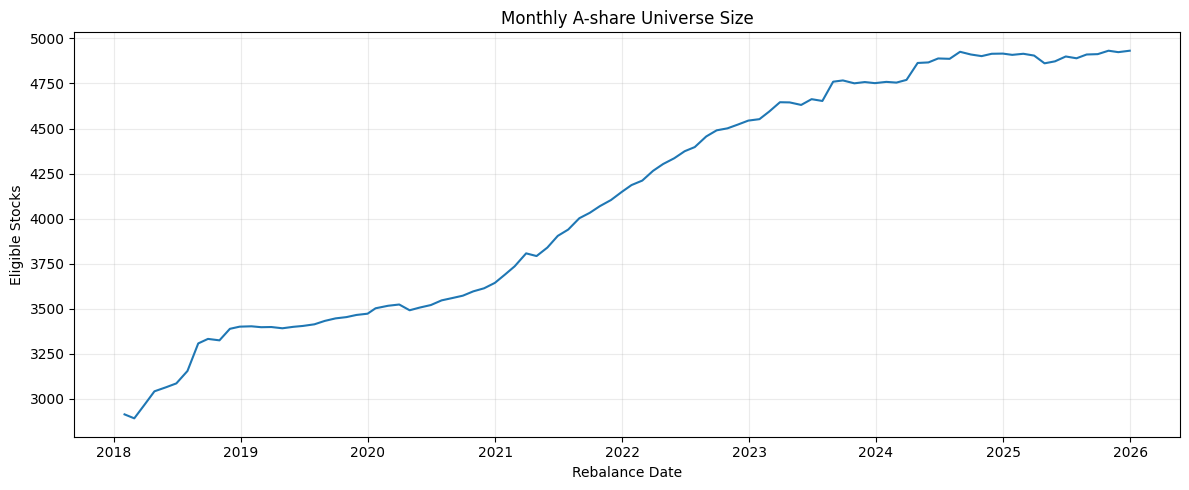

In [16]:
if monthly_summary is None:
    print("没有可绘制的月度股票池汇总数据。")
else:
    figures_directory = PROJECT_ROOT / "figures"
    figures_directory.mkdir(parents=True, exist_ok=True)
    figure_path = figures_directory / "universe_size.png"

    fig, ax = plt.subplots(figsize=(12, 5))
    ax.plot(monthly_summary["date"], monthly_summary["最终股票池数量"], linewidth=1.5)
    ax.set_title("Monthly A-share Universe Size")
    ax.set_xlabel("Rebalance Date")
    ax.set_ylabel("Eligible Stocks")
    ax.grid(alpha=0.25)
    fig.tight_layout()
    fig.savefig(figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{figure_path}")

## 模块 12：补充图表的公共配置

本模块只为后续新增图表准备 NumPy、百分比坐标格式和中文字体，不修改前面的下载或预处理结果。

In [17]:
import numpy as np
from matplotlib.ticker import PercentFormatter

FIGURES_DIRECTORY = PROJECT_ROOT / "figures"
FIGURES_DIRECTORY.mkdir(parents=True, exist_ok=True)

# 优先使用 macOS 常见中文字体，并保留通用字体作为回退。
plt.rcParams["font.sans-serif"] = [
    "PingFang SC",
    "Arial Unicode MS",
    "Heiti TC",
    "DejaVu Sans",
]
plt.rcParams["axes.unicode_minus"] = False

## 模块 13：各行业股票数量分布

为避免把同一股票在不同月份重复计数，本模块使用最新调仓日的合格股票池，展示申万一级行业股票数量。行业为空的股票单独归入“行业缺失”。输出文件为 `figures/industry_distribution.png`。

,stock_count
industry,
机械设备,514
医药生物,453
电子,452
基础化工,393
电力设备,346
计算机,319
汽车,269
轻工制造,148
建筑装饰,139


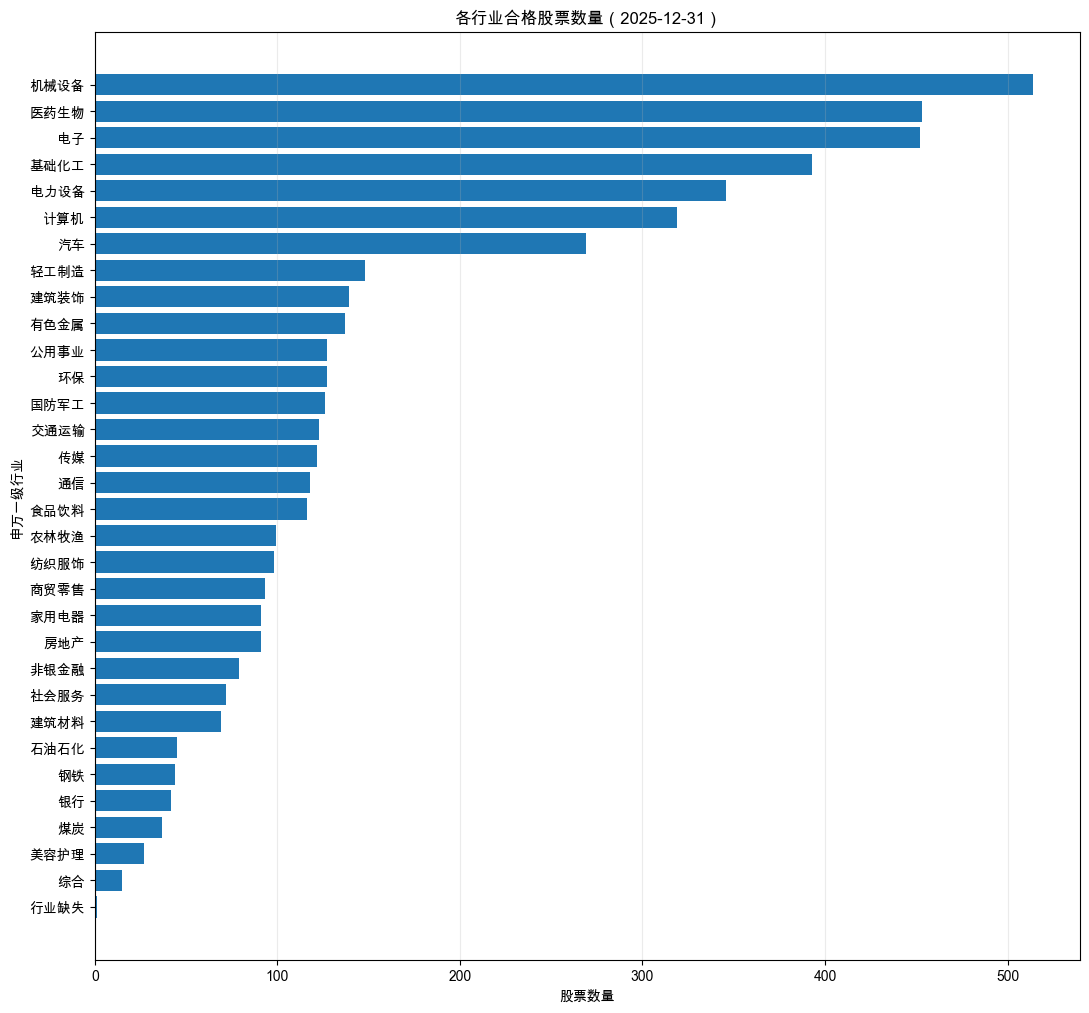

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/industry_distribution.png


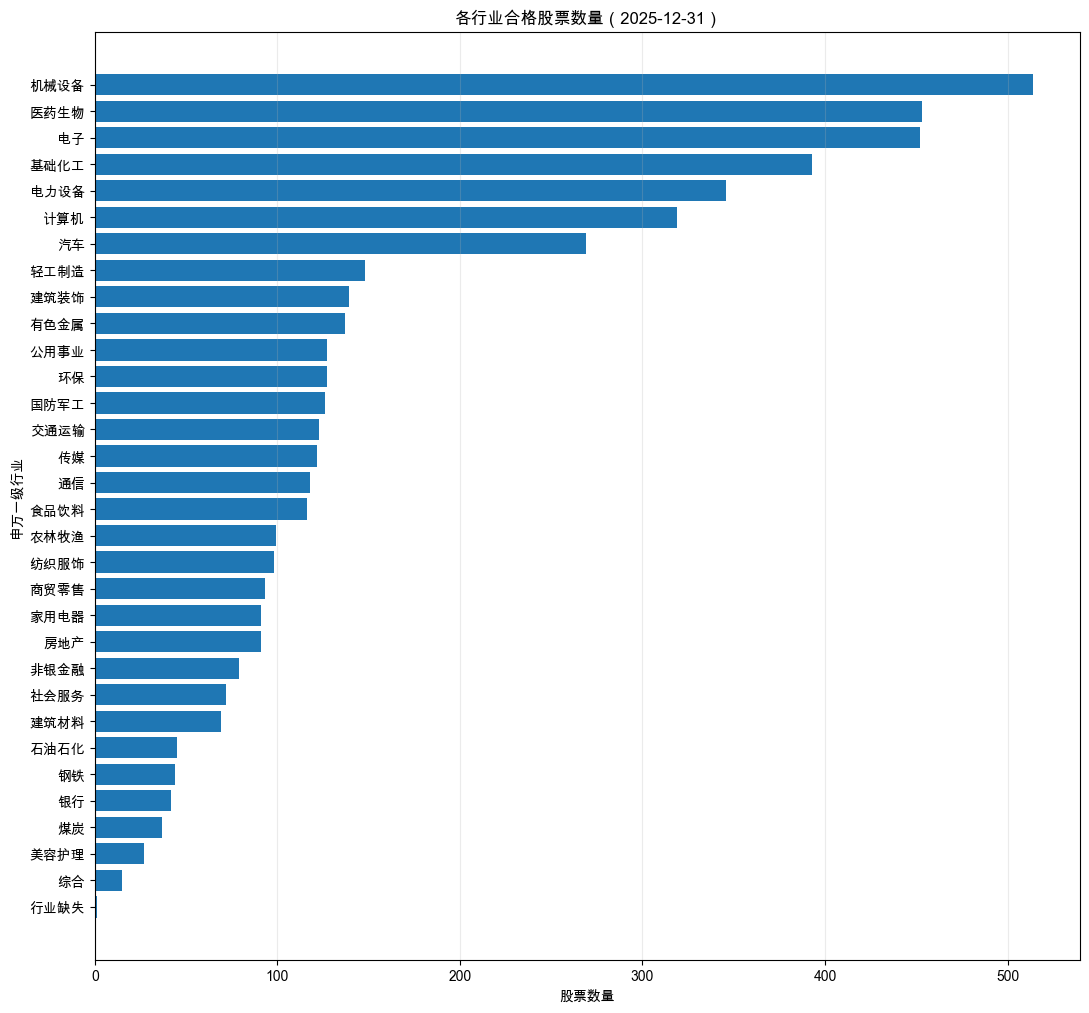

In [18]:
industry_counts = None

if eligible_universe is None or eligible_universe.empty:
    print("没有可用于行业分布分析的合格股票池数据。")
else:
    latest_rebalance_date = eligible_universe["date"].max()
    latest_eligible = eligible_universe.loc[
        eligible_universe["date"].eq(latest_rebalance_date)
    ].copy()
    industry_labels = latest_eligible["industry"].astype("string").fillna("行业缺失")
    industry_counts = (
        industry_labels.value_counts()
        .rename_axis("industry")
        .rename("stock_count")
        .sort_values(ascending=True)
    )

    display(industry_counts.sort_values(ascending=False).to_frame())

    figure_height = max(6, 0.32 * len(industry_counts))
    fig, ax = plt.subplots(figsize=(11, figure_height))
    ax.barh(industry_counts.index, industry_counts.values)
    ax.set_title(f"各行业合格股票数量（{latest_rebalance_date:%Y-%m-%d}）")
    ax.set_xlabel("股票数量")
    ax.set_ylabel("申万一级行业")
    ax.grid(axis="x", alpha=0.25)
    fig.tight_layout()

    industry_figure_path = FIGURES_DIRECTORY / "industry_distribution.png"
    fig.savefig(industry_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{industry_figure_path}")

## 模块 14：市值与 log 市值分布

本模块使用最新调仓日合格股票的总市值。左图展示原始市值并将横轴限制在 99.5% 分位以内，避免少数超大市值股票压缩主体分布；右图对全部正市值取自然对数。输出文件为 `figures/market_cap_distribution.png`。

,market_cap_100m_cny
quantile,
0.00,6.918243
0.01,19.380668
0.05,25.023992
0.25,41.991935
0.50,72.565811
0.75,155.045566
0.95,681.387193
0.99,2385.224513
1.00,28263.016187


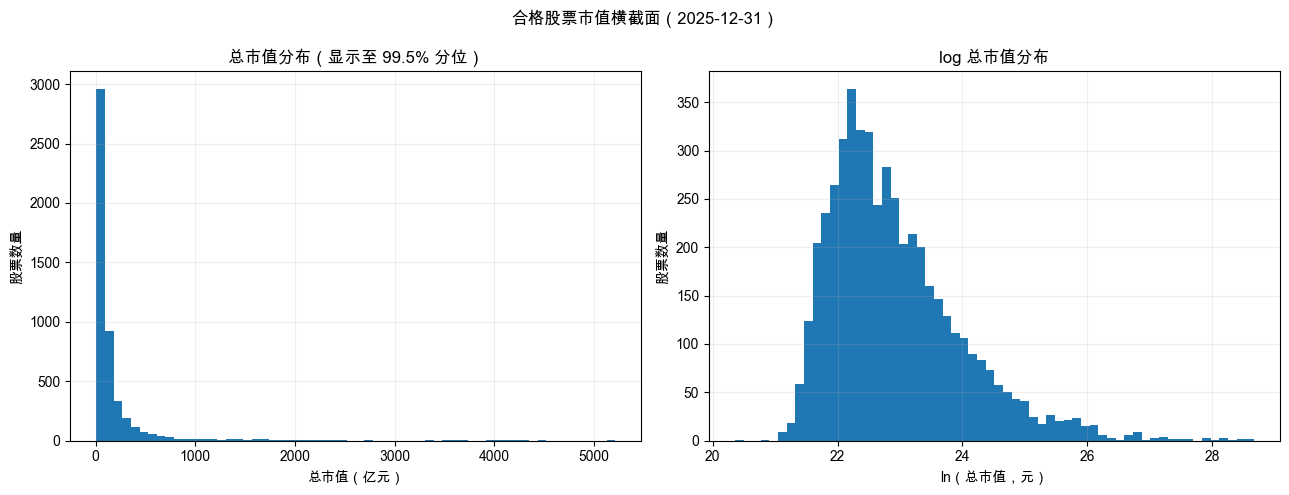

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/market_cap_distribution.png


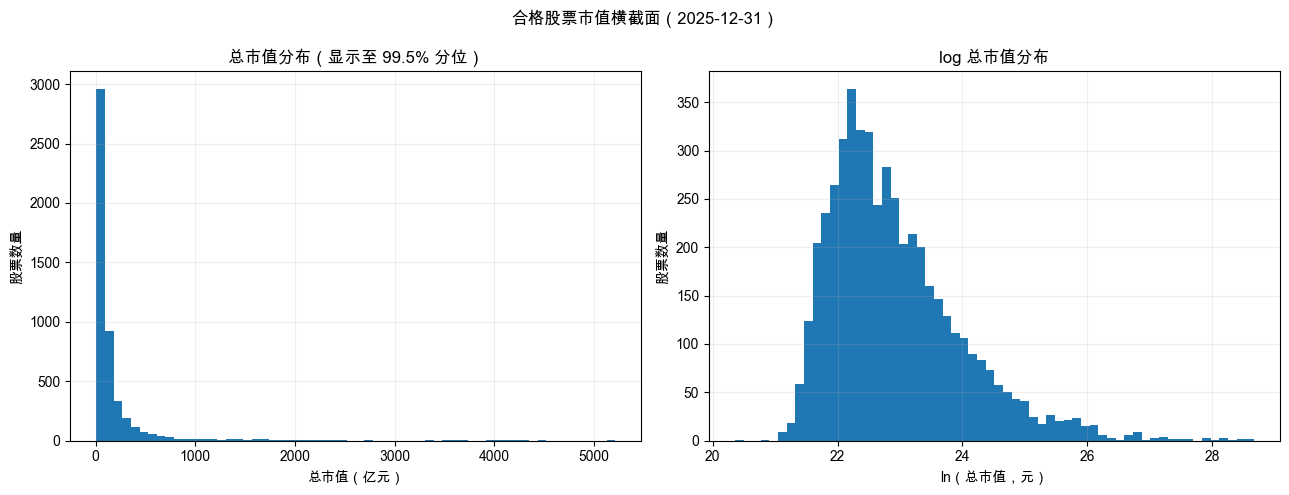

In [19]:
market_cap_distribution = None

if eligible_universe is None or eligible_universe.empty:
    print("没有可用于市值分布分析的合格股票池数据。")
else:
    market_cap_date = eligible_universe["date"].max()
    market_cap = pd.to_numeric(
        eligible_universe.loc[
            eligible_universe["date"].eq(market_cap_date),
            "market_cap",
        ],
        errors="coerce",
    ).dropna()
    market_cap = market_cap.loc[market_cap.gt(0)]
    market_cap_distribution = pd.DataFrame(
        {
            "market_cap_100m_cny": market_cap / 1e8,
            "log_market_cap": np.log(market_cap),
        }
    )

    market_cap_summary = (
        market_cap.quantile([0, 0.01, 0.05, 0.25, 0.50, 0.75, 0.95, 0.99, 1.00])
        .div(1e8)
        .rename("market_cap_100m_cny")
        .to_frame()
    )
    market_cap_summary.index.name = "quantile"
    display(market_cap_summary)

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    raw_cap = market_cap_distribution["market_cap_100m_cny"]
    raw_cap_limit = raw_cap.quantile(0.995)
    axes[0].hist(raw_cap.loc[raw_cap.le(raw_cap_limit)], bins=60)
    axes[0].set_title("总市值分布（显示至 99.5% 分位）")
    axes[0].set_xlabel("总市值（亿元）")
    axes[0].set_ylabel("股票数量")

    axes[1].hist(market_cap_distribution["log_market_cap"], bins=60)
    axes[1].set_title("log 总市值分布")
    axes[1].set_xlabel("ln（总市值，元）")
    axes[1].set_ylabel("股票数量")

    for ax in axes:
        ax.grid(alpha=0.2)
    fig.suptitle(f"合格股票市值横截面（{market_cap_date:%Y-%m-%d}）")
    fig.tight_layout()

    market_cap_figure_path = FIGURES_DIRECTORY / "market_cap_distribution.png"
    fig.savefig(market_cap_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{market_cap_figure_path}")

## 模块 15：每日与每月缺失率

每日缺失率按 `price_daily` 的行情、复权、市值和涨跌停核心字段计算；每月缺失率按 `universe_monthly` 的行业、市值和财务核心字段计算。月度部分使用全部月末候选记录，而不是只使用已通过完整性筛选的股票，以免人为得到接近零的缺失率。输出文件为 `figures/missing_rate.png`。

,dataset,field,missing_rate_percent
9,price_daily,up_limit_price,0.796341
10,price_daily,down_limit_price,0.796341
8,price_daily,market_cap,0.782305
4,price_daily,prev_close,0.001202
0,price_daily,open,0.000000
1,price_daily,high,0.000000
2,price_daily,low,0.000000
3,price_daily,close,0.000000
5,price_daily,volume,0.000000
6,price_daily,amount,0.000000


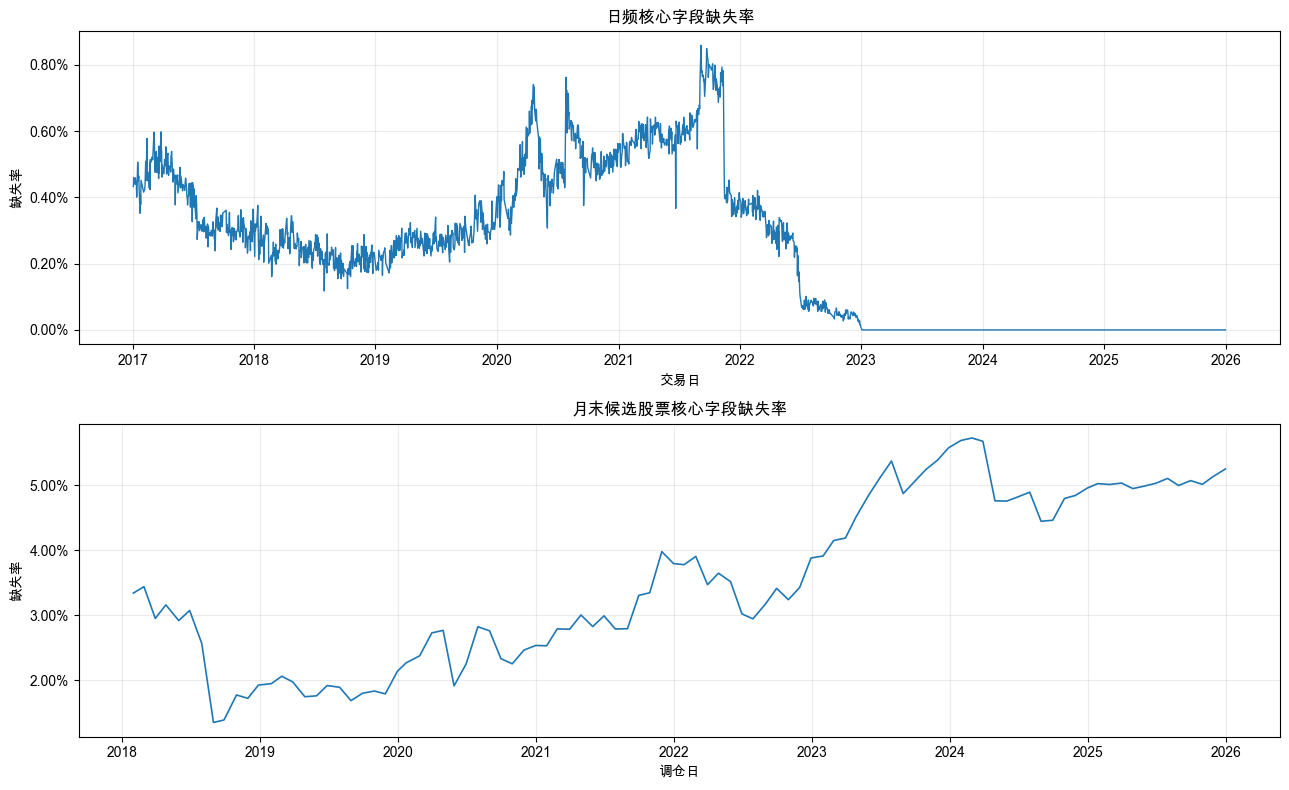

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/missing_rate.png


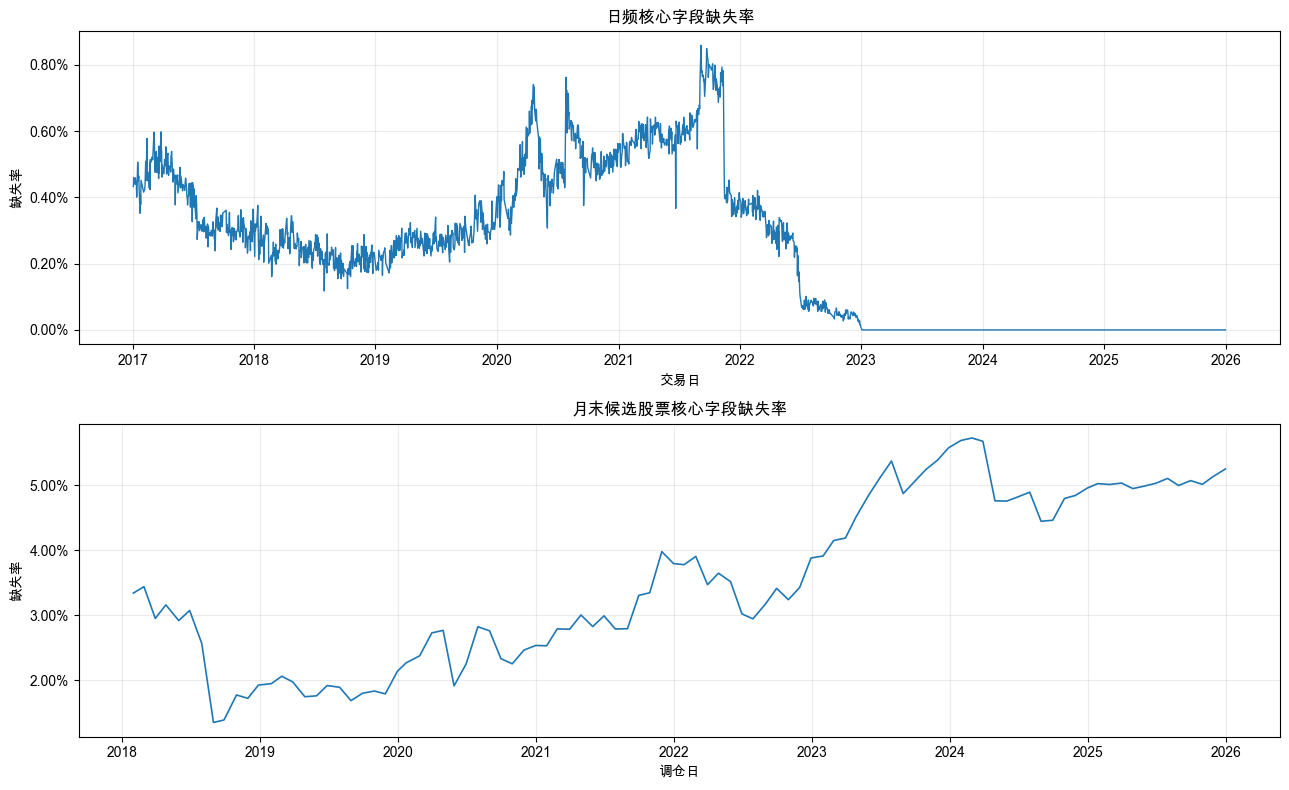

In [20]:
daily_missing_rate = None
monthly_missing_rate = None

if price_daily is None or universe_monthly is None:
    print("没有完整加载 price_daily 和 universe_monthly，无法计算缺失率。")
else:
    requested_daily_fields = [
        "open", "high", "low", "close", "prev_close",
        "volume", "amount", "adj_factor", "market_cap",
        "up_limit_price", "down_limit_price",
    ]
    requested_monthly_fields = [
        "industry", "market_cap", "total_assets", "total_equity",
        "net_profit_ttm", "revenue_ttm", "gross_profit_ttm",
        "end_date", "announcement_date",
    ]
    daily_fields = [field for field in requested_daily_fields if field in price_daily.columns]
    monthly_fields = [
        field for field in requested_monthly_fields if field in universe_monthly.columns
    ]

    missing_daily_fields = sorted(set(requested_daily_fields) - set(daily_fields))
    missing_monthly_fields = sorted(set(requested_monthly_fields) - set(monthly_fields))
    if missing_daily_fields or missing_monthly_fields:
        print(
            f"未参与计算的缺失字段：daily={missing_daily_fields}, "
            f"monthly={missing_monthly_fields}"
        )

    daily_missing_by_field = pd.concat(
        {
            field: price_daily[field].isna().groupby(price_daily["date"]).mean()
            for field in daily_fields
        },
        axis=1,
    ).sort_index()
    monthly_missing_by_field = pd.concat(
        {
            field: universe_monthly[field].isna().groupby(universe_monthly["date"]).mean()
            for field in monthly_fields
        },
        axis=1,
    ).sort_index()

    daily_missing_rate = daily_missing_by_field.mean(axis=1).rename("missing_rate")
    monthly_missing_rate = monthly_missing_by_field.mean(axis=1).rename("missing_rate")

    missing_by_field = pd.concat(
        [
            price_daily[daily_fields].isna().mean().rename("missing_rate").to_frame()
            .assign(dataset="price_daily"),
            universe_monthly[monthly_fields].isna().mean().rename("missing_rate").to_frame()
            .assign(dataset="universe_monthly"),
        ]
    ).reset_index(names="field")
    missing_by_field["missing_rate_percent"] = 100 * missing_by_field["missing_rate"]
    display(
        missing_by_field.sort_values(
            ["dataset", "missing_rate"], ascending=[True, False]
        )[["dataset", "field", "missing_rate_percent"]]
    )

    fig, axes = plt.subplots(2, 1, figsize=(13, 8), sharex=False)
    axes[0].plot(daily_missing_rate.index, daily_missing_rate.values, linewidth=1.0)
    axes[0].set_title("日频核心字段缺失率")
    axes[0].set_xlabel("交易日")
    axes[0].set_ylabel("缺失率")
    axes[0].yaxis.set_major_formatter(PercentFormatter(1.0))

    axes[1].plot(monthly_missing_rate.index, monthly_missing_rate.values, linewidth=1.2)
    axes[1].set_title("月末候选股票核心字段缺失率")
    axes[1].set_xlabel("调仓日")
    axes[1].set_ylabel("缺失率")
    axes[1].yaxis.set_major_formatter(PercentFormatter(1.0))

    for ax in axes:
        ax.grid(alpha=0.25)
    fig.tight_layout()

    missing_figure_path = FIGURES_DIRECTORY / "missing_rate.png"
    fig.savefig(missing_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{missing_figure_path}")

## 模块 16：收益率极端值分布

本模块使用 `close × adj_factor` 构造复权收盘价，并按股票计算相邻有效行情记录之间的收益率。左图展示 0.1%—99.9% 分位区间，右图统计不同绝对收益阈值的观测数量；同时输出绝对收益最大的记录，便于检查停牌复牌、上市初期或数据异常。输出文件为 `figures/return_extremes.png`。

,return_percent
quantile,
0.000,-96.443089
0.001,-13.333961
0.010,-8.441558
0.050,-4.400000
0.500,0.000000
0.950,4.885057
0.990,10.001935
0.999,19.997408
1.000,200400.235128


,date,stock_code,previous_date,gap_calendar_days,close,adj_factor,return_percent,absolute_return_percent
4684484,2022-02-25,920227.BJ,2017-10-18,1591.0,20.05,938.0000,200400.235128,200400.235128
2541537,2020-02-04,920427.BJ,2017-11-15,811.0,10.96,100.0000,109500.000000,109500.000000
7088471,2024-02-02,920656.BJ,2021-01-26,1102.0,19.90,10.0000,5585.714286,5585.714286
4915167,2022-05-11,920199.BJ,2017-12-29,1594.0,50.00,3.7895,5163.194444,5163.194444
2598922,2020-02-25,920892.BJ,2017-09-25,883.0,19.63,7.7551,3906.121395,3906.121395
28924,2017-01-16,920719.BJ,2017-01-13,3.0,9.80,1.0000,880.000000,880.000000
6822063,2023-11-23,920570.BJ,2022-09-13,436.0,67.10,1.0510,659.936422,659.936422
158823,2017-03-24,920670.BJ,2017-02-21,31.0,13.00,1.0000,550.000000,550.000000
5259249,2022-08-22,000670.SZ,2020-03-19,886.0,13.24,10.0900,488.450276,488.450276
4362471,2021-11-15,920454.BJ,2021-04-26,203.0,23.45,1.0548,486.250000,486.250000


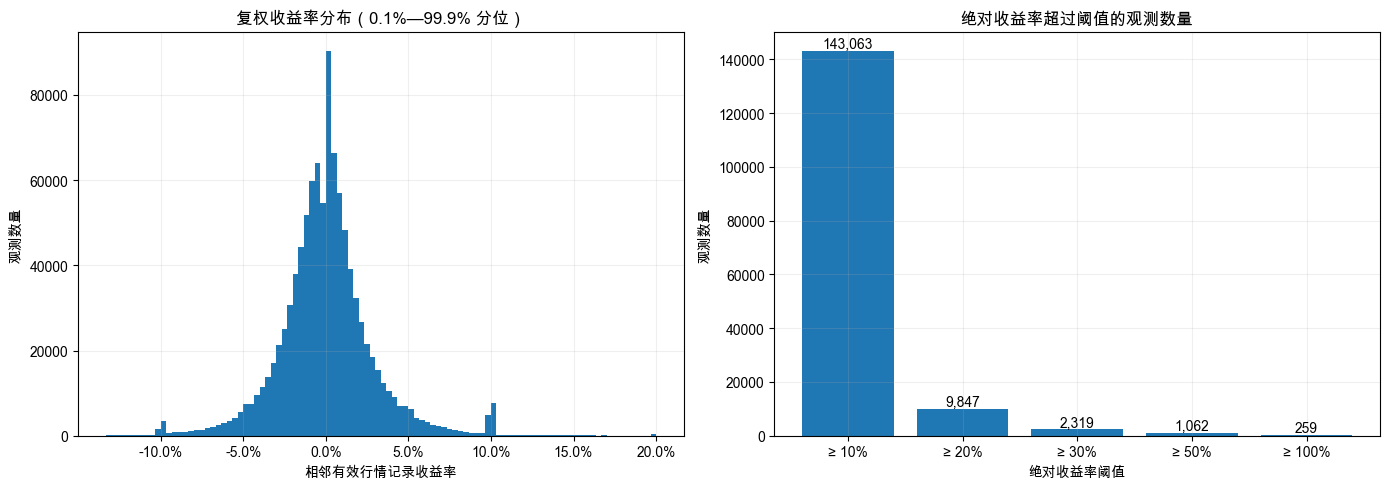

图表已保存至：/Users/mac/Desktop/a-share-multifactor/figures/return_extremes.png


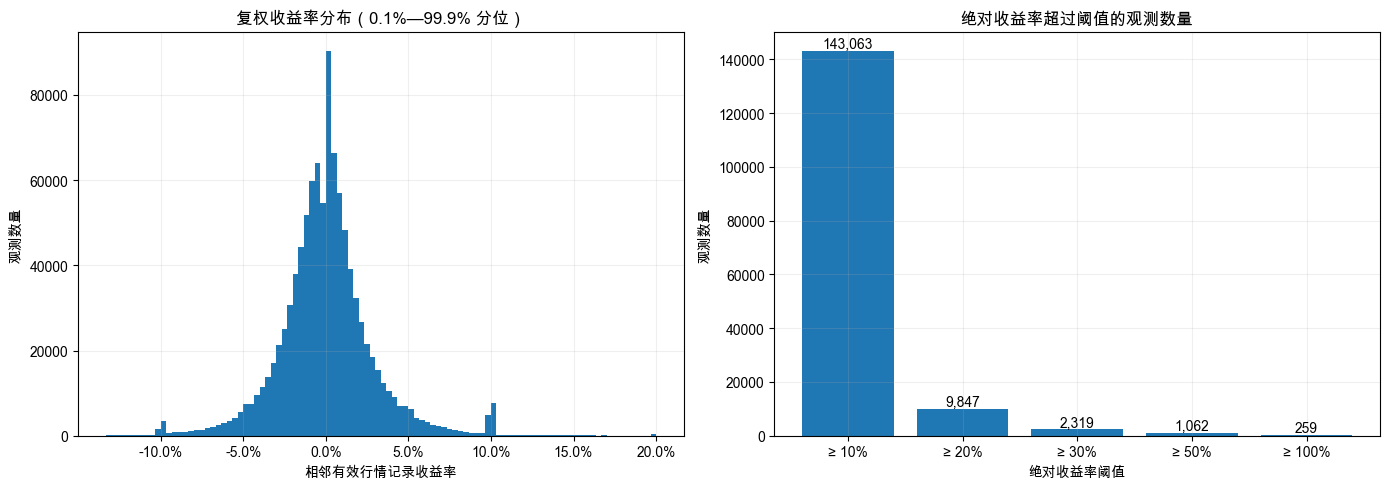

In [21]:
return_observations = None

if price_daily is None:
    print("没有加载 price_daily，无法计算收益率。")
else:
    return_frame = price_daily[["date", "stock_code", "close", "adj_factor"]].copy()
    return_frame["close"] = pd.to_numeric(return_frame["close"], errors="coerce")
    return_frame["adj_factor"] = pd.to_numeric(
        return_frame["adj_factor"], errors="coerce"
    )
    return_frame = return_frame.sort_values(["stock_code", "date"])
    return_frame["adjusted_close"] = return_frame["close"] * return_frame["adj_factor"]
    return_frame["previous_date"] = return_frame.groupby("stock_code")["date"].shift()
    return_frame["return"] = (
        return_frame.groupby("stock_code")["adjusted_close"]
        .pct_change(fill_method=None)
    )
    return_frame["gap_calendar_days"] = (
        return_frame["date"] - return_frame["previous_date"]
    ).dt.days
    return_frame["return"] = return_frame["return"].replace([np.inf, -np.inf], np.nan)
    return_observations = return_frame.dropna(subset=["return"]).copy()
    return_observations["absolute_return"] = return_observations["return"].abs()

    return_quantiles = (
        return_observations["return"]
        .quantile([0, 0.001, 0.01, 0.05, 0.50, 0.95, 0.99, 0.999, 1.00])
        .mul(100)
        .rename("return_percent")
        .to_frame()
    )
    return_quantiles.index.name = "quantile"
    display(return_quantiles)

    extreme_records = return_observations.nlargest(20, "absolute_return")[
        [
            "date", "stock_code", "previous_date", "gap_calendar_days",
            "close", "adj_factor", "return", "absolute_return",
        ]
    ].copy()
    extreme_records["return_percent"] = 100 * extreme_records["return"]
    extreme_records["absolute_return_percent"] = 100 * extreme_records["absolute_return"]
    display(
        extreme_records.drop(columns=["return", "absolute_return"])
    )

    lower_bound, upper_bound = return_observations["return"].quantile([0.001, 0.999])
    central_returns = return_observations.loc[
        return_observations["return"].between(lower_bound, upper_bound),
        "return",
    ]
    if len(central_returns) > 1_000_000:
        central_returns = central_returns.sample(1_000_000, random_state=42)

    thresholds = pd.Series([0.10, 0.20, 0.30, 0.50, 1.00], name="threshold")
    tail_counts = pd.Series(
        {threshold: return_observations["absolute_return"].ge(threshold).sum() for threshold in thresholds}
    ).sort_index()

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].hist(central_returns, bins=100)
    axes[0].set_title("复权收益率分布（0.1%—99.9% 分位）")
    axes[0].set_xlabel("相邻有效行情记录收益率")
    axes[0].set_ylabel("观测数量")
    axes[0].xaxis.set_major_formatter(PercentFormatter(1.0))

    threshold_labels = [f"≥ {threshold:.0%}" for threshold in tail_counts.index]
    axes[1].bar(threshold_labels, tail_counts.values)
    axes[1].set_title("绝对收益率超过阈值的观测数量")
    axes[1].set_xlabel("绝对收益率阈值")
    axes[1].set_ylabel("观测数量")
    for position, count in enumerate(tail_counts.values):
        axes[1].text(position, count, f"{count:,}", ha="center", va="bottom")

    for ax in axes:
        ax.grid(alpha=0.2)
    fig.tight_layout()

    return_figure_path = FIGURES_DIRECTORY / "return_extremes.png"
    fig.savefig(return_figure_path, dpi=150, bbox_inches="tight")
    display(fig)
    print(f"图表已保存至：{return_figure_path}")

# 模块17:数据质量评估

